# Modelado y evaluación

Notebook dedicado al entrenamiento, comparación y evaluación de modelos de regresión sobre los datos limpios generados por el notebook 1 (results/df_clean_initial.csv), a partir de los cuales se construyen aquí los splits de train/val/test para cada target.

## 1. Carga de datos y preparación de splits

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reutilizamos funciones del paquete `src`
from src.data_io import load_clean_df
from src.preprocessing import build_dataset_for_target
from src.models import get_baseline_models, tune_pls_components
from src.training import save_model, load_model
from src.metrics import regression_metrics

sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'results' / 'df_clean_initial.csv'
META_PATH = BASE_DIR / 'results' / 'df_meta_initial.json'
MODEL_ROOT_DIR = BASE_DIR / 'results' / 'modelado'
MODEL_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# Cargamos usando la función centralizada 
df_raw, meta = load_clean_df(DATA_PATH, META_PATH)

# Compatibilidad con distintas versiones de la estructura de meta
meta_targets = meta.get('targets', meta.get('target_cols', []))
available_targets = [t for t in meta_targets if t in df_raw.columns]
if not available_targets:
    raise ValueError('No se detectaron variables objetivo válidas en el dataset limpio. Comprueba keys en results/df_meta_initial.json')

TARGET_NAME = 'tss_' if 'tss_' in available_targets else available_targets[0]
TARGET_DIR = MODEL_ROOT_DIR / TARGET_NAME
TARGET_DIR.mkdir(parents=True, exist_ok=True)

spec_cols = [c for c in meta.get('spec_cols', meta.get('spectral_cols', [])) if c in df_raw.columns]
morf_cols = [c for c in meta.get('morf_cols', meta.get('morpho_cols', [])) if c in df_raw.columns]
cat_cols = [c for c in meta.get('cat_cols', meta.get('categorical_cols', []))
            if c in df_raw.columns
            and not str(c).lower().startswith('unnamed')
            and df_raw[c].nunique() < len(df_raw)]

print('Variables objetivo disponibles:', available_targets)
print('Target seleccionado por defecto:', TARGET_NAME)
print('Bandas espectrales:', len(spec_cols))
print('Variables morfológicas:', morf_cols)
print('Variables categóricas:', cat_cols)

# Construimos los datasets para el target usando la función extraída
# Pasamos explícitamente las listas detectadas para evitar discrepancias en claves de meta
data_bundle = build_dataset_for_target(
    df_raw,
    meta,
    TARGET_NAME,
    spectral_cols=spec_cols,
    cat_cols=cat_cols,
    morf_cols=morf_cols,
    group_col=meta.get('group_col')
)

X_train = data_bundle['X_train']
X_val = data_bundle['X_val']
X_test = data_bundle['X_test']
X_train_spec = data_bundle['X_train_spec']
X_val_spec = data_bundle['X_val_spec']
X_test_spec = data_bundle['X_test_spec']
y_train = data_bundle['y_train']
y_val = data_bundle['y_val']
y_test = data_bundle['y_test']
TARGET_NAME = data_bundle['target_name']

print('Shapes cargadas para el target:', TARGET_NAME)
print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)
print('X_train_spec:', X_train_spec.shape, 'X_val_spec:', X_val_spec.shape, 'X_test_spec:', X_test_spec.shape)
print('y_train:', y_train.shape, 'y_val:', y_val.shape, 'y_test:', y_test.shape)
print('\nVista rápida de columnas:')
print(X_train.columns[:10].tolist())
print('\nValores faltantes por conjunto:')
print('X_train:', int(X_train.isna().sum().sum()))
print('X_val  :', int(X_val.isna().sum().sum()))
print('X_test :', int(X_test.isna().sum().sum()))
print('y_train:', int(y_train.isna().sum()))
print('y_val  :', int(y_val.isna().sum()))
print('y_test :', int(y_test.isna().sum()))


Variables objetivo disponibles: ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1']
Target seleccionado por defecto: tss_
Bandas espectrales: 212
Variables morfológicas: ['weight_g', 'length_mm', 'diameter_mm']
Variables categóricas: ['variety', 'clon_type', 'origin']
Shapes cargadas para el target: tss_
X_train: (431, 231) X_val: (196, 231) X_test: (350, 231)
X_train_spec: (431, 212) X_val_spec: (196, 212) X_test_spec: (350, 212)
y_train: (431,) y_val: (196,) y_test: (350,)

Vista rápida de columnas:
['950.939', '954.809', '958.674', '962.537', '966.395', '970.25', '974.102', '977.95', '981.794', '985.635']

Valores faltantes por conjunto:
X_train: 0
X_val  : 0
X_test : 0
y_train: 0
y_val  : 0
y_test : 0


 ## 2. Inspección de los splits

,split,n_samples,tss__mean,tss__std,tss__min,tss__median,tss__max
0,train,431,8.108121,0.977659,6.1,8.1,10.6
1,validation,196,8.044388,0.953546,6.1,8.1,10.4
2,test,350,7.351429,1.116475,5.5,7.5,9.6


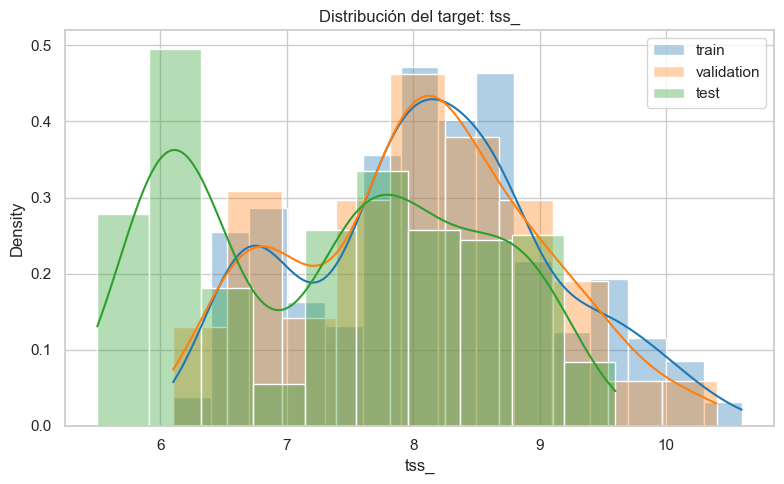

In [25]:
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    f'{TARGET_NAME}_mean': [y_train.mean(), y_val.mean(), y_test.mean()],
    f'{TARGET_NAME}_std': [y_train.std(), y_val.std(), y_test.std()],
    f'{TARGET_NAME}_min': [y_train.min(), y_val.min(), y_test.min()],
    f'{TARGET_NAME}_median': [y_train.median(), y_val.median(), y_test.median()],
    f'{TARGET_NAME}_max': [y_train.max(), y_val.max(), y_test.max()],
})

display(split_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_train, color='tab:blue', label='train', kde=True, stat='density', alpha=0.35, ax=ax)
sns.histplot(y_val, color='tab:orange', label='validation', kde=True, stat='density', alpha=0.35, ax=ax)
sns.histplot(y_test, color='tab:green', label='test', kde=True, stat='density', alpha=0.35, ax=ax)
ax.set_title(f'Distribución del target: {TARGET_NAME}')
ax.set_xlabel(TARGET_NAME)
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)


## 3. Modelos de referencia (baseline)

In [26]:
from sklearn.base import clone

# Wrapper local para evaluar modelos directamente en el notebook

def evaluate_model_nb(name, estimator, X_fit, y_fit, X_eval, y_eval, feature_set='full'):
    model = clone(estimator)
    model.fit(X_fit, y_fit)
    preds = np.asarray(model.predict(X_eval)).ravel()
    metrics = regression_metrics(y_eval, preds)
    metrics['model'] = name
    metrics['feature_set'] = feature_set
    return model, preds, metrics

# definir componentes por defecto para PLS según dimensiones disponibles
pls_default_components = max(1, min(10, X_train_spec.shape[1], X_train_spec.shape[0] - 1))

# obtener modelos base desde src.models
raw_models = get_baseline_models(pls_components=pls_default_components)

baseline_models = {}
for name, est in raw_models.items():
    feature_set = 'spectral' if name.upper().startswith('PLS') else 'full'
    baseline_models[name if name!='PLS' else 'PLSRegression_default'] = {
        'estimator': est,
        'feature_set': feature_set,
    }

baseline_results = []
model_registry = {}
validation_predictions = {}

for name, config in baseline_models.items():
    if config['feature_set'] == 'spectral':
        X_fit, X_eval = X_train_spec, X_val_spec
    else:
        X_fit, X_eval = X_train, X_val
    model, preds, metrics = evaluate_model_nb(
        name,
        config['estimator'],
        X_fit,
        y_train,
        X_eval,
        y_val,
        feature_set=config['feature_set'],
    )
    model_registry[name] = model
    validation_predictions[name] = preds
    baseline_results.append(metrics)

baseline_results = pd.DataFrame(baseline_results).sort_values(['rmse', 'mae']).reset_index(drop=True)
display(baseline_results)

best_baseline_name = baseline_results.iloc[0]['model']
best_baseline_model = model_registry[best_baseline_name]
best_baseline_val_pred = validation_predictions[best_baseline_name]

print('Mejor modelo base según RMSE en validación:', best_baseline_name)
print('Datos usados:', baseline_results.loc[baseline_results['model'] == best_baseline_name, 'feature_set'].iloc[0])


,mae,rmse,r2,model,feature_set
0,0.314075,0.406211,0.817593,Ridge,full
1,0.357855,0.444134,0.781945,LinearRegression,full
2,0.345903,0.447986,0.778146,RandomForest,full
3,0.465839,0.682924,0.484436,PLSRegression_default,spectral
4,0.759419,0.953244,-0.004490,DummyMean,full
5,0.759419,0.953244,-0.004490,Lasso,full


Mejor modelo base según RMSE en validación: Ridge
Datos usados: full


### 3.1 Diagnóstico visual del mejor modelo base

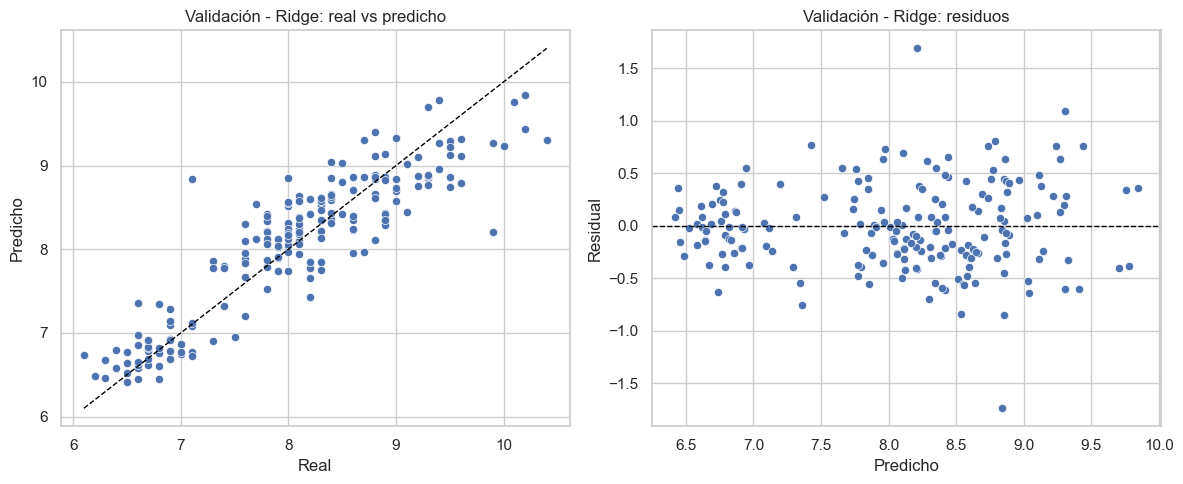

In [27]:
def plot_regression_diagnostics(y_true, y_pred, title_prefix='Validation'):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0], s=35)
    min_val = min(float(np.min(y_true)), float(np.min(y_pred)))
    max_val = max(float(np.max(y_true)), float(np.max(y_pred)))
    axes[0].plot([min_val, max_val], [min_val, max_val], '--', color='black', linewidth=1)
    axes[0].set_title(f'{title_prefix}: real vs predicho')
    axes[0].set_xlabel('Real')
    axes[0].set_ylabel('Predicho')

    sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], s=35)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title(f'{title_prefix}: residuos')
    axes[1].set_xlabel('Predicho')
    axes[1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_regression_diagnostics(y_val, best_baseline_val_pred, title_prefix=f'Validación - {best_baseline_name}')

## 4. Ajuste de hiperparámetros PLS

,param_n_components,mean_test_score,std_test_score,rmse
0,1,-0.940864,0.014021,0.940864
1,2,-0.840012,0.040790,0.840012
2,3,-0.796326,0.048433,0.796326
3,4,-0.739340,0.025350,0.739340
4,5,-0.684828,0.030929,0.684828
5,6,-0.664229,0.039435,0.664229
6,7,-0.628785,0.038590,0.628785
7,8,-0.610174,0.045927,0.610174
8,9,-0.588642,0.047883,0.588642
9,10,-0.574685,0.044022,0.574685


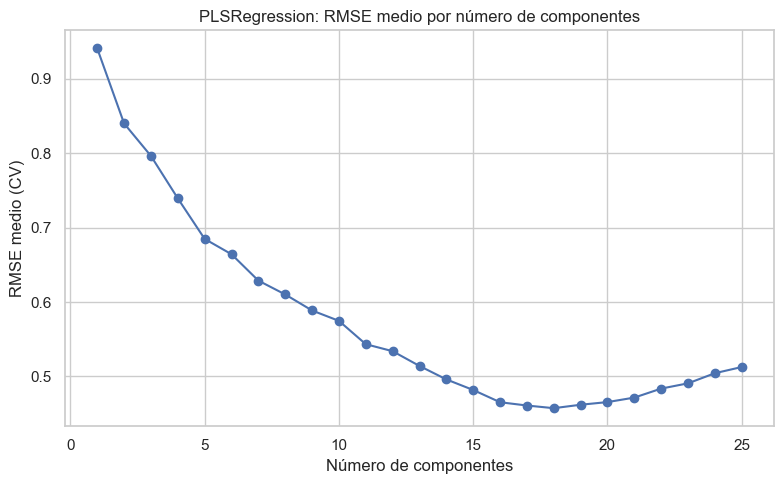

,mae,rmse,r2,model,feature_set,best_params,cv_rmse
0,0.327306,0.445208,0.780889,PLSRegression_tuned,spectral,{'n_components': 18},0.457338


,mae,rmse,r2,model,feature_set,best_params,cv_rmse
0,0.314075,0.406211,0.817593,Ridge,full,NaN,NaN
1,0.357855,0.444134,0.781945,LinearRegression,full,NaN,NaN
2,0.327306,0.445208,0.780889,PLSRegression_tuned,spectral,{'n_components': 18},0.457338
3,0.345903,0.447986,0.778146,RandomForest,full,NaN,NaN
4,0.465839,0.682924,0.484436,PLSRegression_default,spectral,NaN,NaN
5,0.759419,0.953244,-0.004490,DummyMean,full,NaN,NaN
6,0.759419,0.953244,-0.004490,Lasso,full,NaN,NaN


Mejor modelo global según RMSE en validación: Ridge
Otro modelo supera al PLSRegression ajustado en validación.


In [28]:
max_pls_components = max(1, min(25, X_train_spec.shape[1], X_train_spec.shape[0] - 1))
pls_param_list = list(range(1, max_pls_components + 1))

# Usamos la utilidad `tune_pls_components` exportada desde src.models
pls_search = tune_pls_components(X_train_spec, y_train, cv=5, n_components_list=pls_param_list, scoring='neg_root_mean_squared_error')

pls_cv_results = pd.DataFrame(pls_search.cv_results_)[['param_n_components', 'mean_test_score', 'std_test_score']].copy()
pls_cv_results['rmse'] = -pls_cv_results['mean_test_score']
pls_cv_results = pls_cv_results.sort_values('param_n_components').reset_index(drop=True)

display(pls_cv_results)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pls_cv_results['param_n_components'], pls_cv_results['rmse'], marker='o')
ax.set_title('PLSRegression: RMSE medio por número de componentes')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('RMSE medio (CV)')
plt.tight_layout()
plt.show()
plt.close(fig)

best_pls_model = pls_search.best_estimator_
best_pls_name = 'PLSRegression_tuned'
pls_val_pred = np.asarray(best_pls_model.predict(X_val_spec)).ravel()
pls_val_metrics = regression_metrics(y_val, pls_val_pred)
pls_val_metrics.update({
    'model': best_pls_name,
    'feature_set': 'spectral',
    'best_params': pls_search.best_params_,
    'cv_rmse': -pls_search.best_score_,
})

model_registry[best_pls_name] = best_pls_model
validation_predictions[best_pls_name] = pls_val_pred

pls_summary = pd.DataFrame([pls_val_metrics])
display(pls_summary)

comparison_results = pd.concat([
    baseline_results,
    pls_summary[['model', 'feature_set', 'mae', 'rmse', 'r2', 'best_params', 'cv_rmse']],
], ignore_index=True, sort=False).sort_values(['rmse', 'mae']).reset_index(drop=True)

display(comparison_results)

best_overall_name = comparison_results.iloc[0]['model']
best_overall_model = model_registry[best_overall_name]
best_overall_val_pred = validation_predictions[best_overall_name]

print('Mejor modelo global según RMSE en validación:', best_overall_name)
if best_overall_name == best_pls_name:
    print('El modelo PLSRegression ajustado es el mejor candidato.')
else:
    print('Otro modelo supera al PLSRegression ajustado en validación.')


## 5. Evaluación final en test

,model,split,feature_set,mae,rmse,r2
0,Ridge,test,full,0.679255,0.782981,0.506772


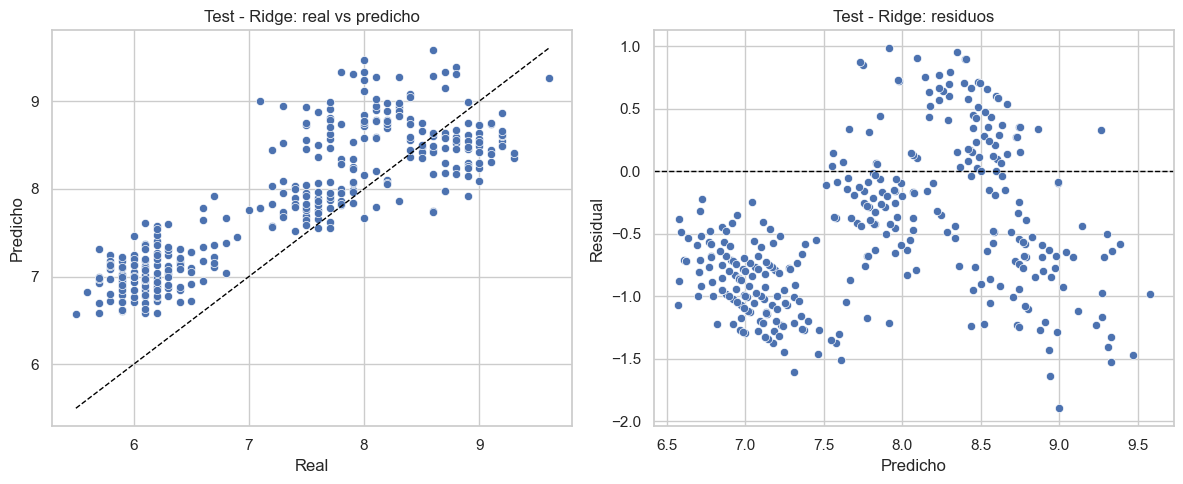

Modelo guardado en: c:\Users\mirei\OneDrive\Escritorio\TFG\results\modelado\tss_\ridge_model.joblib
Métricas tras recargar el modelo: {'mae': 0.6792551142556104, 'rmse': 0.7829814999245018, 'r2': 0.5067721849184774}
Archivos guardados en: c:\Users\mirei\OneDrive\Escritorio\TFG\results\modelado\tss_


In [29]:
# Evaluación en test usando el mejor modelo seleccionado
best_feature_set = comparison_results.loc[comparison_results['model'] == best_overall_name, 'feature_set'].iloc[0]
if best_feature_set == 'full':
    X_test_used = X_test
else:
    X_test_used = X_test_spec

best_test_pred = np.asarray(best_overall_model.predict(X_test_used)).ravel()
best_test_metrics = regression_metrics(y_test, best_test_pred)

final_results = pd.DataFrame([
    {
        'model': best_overall_name,
        'split': 'test',
        'feature_set': best_feature_set,
        'mae': best_test_metrics['mae'],
        'rmse': best_test_metrics['rmse'],
        'r2': best_test_metrics['r2'],
    }
])

display(final_results)
plot_regression_diagnostics(y_test, best_test_pred, title_prefix=f'Test - {best_overall_name}')

safe_model_name = best_overall_name.lower().replace(' ', '_')
model_path = TARGET_DIR / f'{safe_model_name}_model.joblib'
# Guardamos y recargamos usando las utilidades del paquete src
save_model(best_overall_model, model_path)
print('Modelo guardado en:', model_path)

loaded_model = load_model(model_path)
loaded_test_pred = np.asarray(loaded_model.predict(X_test_used)).ravel()
loaded_test_metrics = regression_metrics(y_test, loaded_test_pred)
print('Métricas tras recargar el modelo:', loaded_test_metrics)

predictions_output = pd.DataFrame({
    'y_true': y_test,
    'y_pred': best_test_pred,
    'residual': y_test - best_test_pred,
}, index=X_test.index)
predictions_output.to_csv(TARGET_DIR / f'{safe_model_name}_test_predictions.csv', index=True)
comparison_results.to_csv(TARGET_DIR / 'validation_comparison.csv', index=False)
final_results.to_csv(TARGET_DIR / 'final_results.csv', index=False)

print('Archivos guardados en:', TARGET_DIR)


## 6. Análisis multi-target

In [30]:
from sklearn.base import clone

all_targets_summary = []
all_validation_rows = []
all_test_rows = []

for target_name in available_targets:
    bundle = build_dataset_for_target(df_raw, meta, target_name)
    Xt, Xv, Xs = bundle['X_train'], bundle['X_val'], bundle['X_test']
    Xt_spec, Xv_spec, Xs_spec = bundle['X_train_spec'], bundle['X_val_spec'], bundle['X_test_spec']
    yt, yv, ys = bundle['y_train'], bundle['y_val'], bundle['y_test']

    # modelos base
    pls_default_components = max(1, min(10, Xt_spec.shape[1], Xt_spec.shape[0] - 1)) if Xt_spec.shape[1] > 0 else 1
    base_models = get_baseline_models(pls_components=pls_default_components)

    val_rows = []
    fitted_models = {}

    for model_name, estimator in base_models.items():
        feature_set = 'spectral' if model_name.upper().startswith('PLS') else 'full'
        if feature_set == 'spectral':
            X_fit, X_eval = Xt_spec, Xv_spec
        else:
            X_fit, X_eval = Xt, Xv

        # si no hay bandas espectrales disponibles, saltar modelos espectrales
        if feature_set == 'spectral' and X_fit.shape[1] == 0:
            continue

        model = clone(estimator)
        model.fit(X_fit, yt)
        pred_val = np.asarray(model.predict(X_eval)).ravel()
        met = regression_metrics(yv, pred_val)
        met.update({
            'target': target_name,
            'model': model_name if model_name != 'PLS' else 'PLSRegression_default',
            'feature_set': feature_set,
            'stage': 'baseline',
        })
        val_rows.append(met)
        fitted_models[met['model']] = (model, feature_set)

    # tuning de PLS
    if Xt_spec.shape[1] > 0:
        max_pls_components = max(1, min(25, Xt_spec.shape[1], Xt_spec.shape[0] - 1))
        pls_search = tune_pls_components(
            Xt_spec,
            yt,
            cv=5,
            n_components_list=list(range(1, max_pls_components + 1)),
            scoring='neg_root_mean_squared_error',
        )
        best_pls = pls_search.best_estimator_
        pred_val_pls = np.asarray(best_pls.predict(Xv_spec)).ravel()
        pls_met = regression_metrics(yv, pred_val_pls)
        pls_met.update({
            'target': target_name,
            'model': 'PLSRegression_tuned',
            'feature_set': 'spectral',
            'stage': 'tuned',
            'best_params': pls_search.best_params_,
            'cv_rmse': -pls_search.best_score_,
        })
        val_rows.append(pls_met)
        fitted_models['PLSRegression_tuned'] = (best_pls, 'spectral')

    val_df = pd.DataFrame(val_rows).sort_values(['rmse', 'mae']).reset_index(drop=True)
    best_name = val_df.iloc[0]['model']
    best_model, best_feature_set = fitted_models[best_name]

    # test del mejor global
    X_test_best = Xs if best_feature_set == 'full' else Xs_spec
    pred_test_best = np.asarray(best_model.predict(X_test_best)).ravel()
    test_best = regression_metrics(ys, pred_test_best)
    test_best.update({
        'target': target_name,
        'model': best_name,
        'feature_set': best_feature_set,
        'split': 'test',
    })

    # mejor full y mejor spectral en validación para comparación directa
    best_full = val_df[val_df['feature_set'] == 'full'].sort_values(['rmse', 'mae']).head(1)
    best_spec = val_df[val_df['feature_set'] == 'spectral'].sort_values(['rmse', 'mae']).head(1)

    best_full_rmse = float(best_full['rmse'].iloc[0]) if not best_full.empty else np.nan
    best_spec_rmse = float(best_spec['rmse'].iloc[0]) if not best_spec.empty else np.nan
    best_full_r2 = float(best_full['r2'].iloc[0]) if not best_full.empty else np.nan
    best_spec_r2 = float(best_spec['r2'].iloc[0]) if not best_spec.empty else np.nan

    all_targets_summary.append({
        'target': target_name,
        'best_model_val': best_name,
        'best_feature_set_val': best_feature_set,
        'best_val_rmse': float(val_df.iloc[0]['rmse']),
        'best_val_r2': float(val_df.iloc[0]['r2']),
        'best_test_rmse': float(test_best['rmse']),
        'best_test_r2': float(test_best['r2']),
        'best_full_rmse_val': best_full_rmse,
        'best_spectral_rmse_val': best_spec_rmse,
        'delta_rmse_full_minus_spectral': best_full_rmse - best_spec_rmse,
        'best_full_r2_val': best_full_r2,
        'best_spectral_r2_val': best_spec_r2,
        'delta_r2_full_minus_spectral': best_full_r2 - best_spec_r2,
    })

    all_validation_rows.append(val_df)
    all_test_rows.append(pd.DataFrame([test_best]))

multi_target_summary = pd.DataFrame(all_targets_summary).sort_values('target').reset_index(drop=True)
multi_target_validation = pd.concat(all_validation_rows, ignore_index=True)
multi_target_test = pd.concat(all_test_rows, ignore_index=True)

print('Resumen multi-target generado.')
display(multi_target_summary)

print('\nTop 3 modelos por target en validación:')
display(
    multi_target_validation.sort_values(['target', 'rmse', 'mae'])
    .groupby('target', as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print('\nResultados test (mejor modelo por target):')
display(multi_target_test.sort_values('target').reset_index(drop=True))

summary_dir = MODEL_ROOT_DIR / 'summary_multi_target'
summary_dir.mkdir(parents=True, exist_ok=True)
multi_target_summary.to_csv(summary_dir / 'multi_target_summary.csv', index=False)
multi_target_validation.to_csv(summary_dir / 'multi_target_validation_all_models.csv', index=False)
multi_target_test.to_csv(summary_dir / 'multi_target_test_best_models.csv', index=False)
print(f'Tablas guardadas en: {summary_dir}')

Resumen multi-target generado.


,target,best_model_val,best_feature_set_val,best_val_rmse,best_val_r2,best_test_rmse,best_test_r2,best_full_rmse_val,best_spectral_rmse_val,delta_rmse_full_minus_spectral,best_full_r2_val,best_spectral_r2_val,delta_r2_full_minus_spectral
0,ta_g_100ml-1,RandomForest,full,0.485377,0.766211,0.689830,0.388908,0.485377,0.562028,-0.076651,0.766211,0.686541,0.079670
1,tpc_juice_mg_100_ml1,Ridge,full,7.068097,0.456371,7.708812,-0.067265,7.068097,7.620138,-0.552041,0.456371,0.368137,0.088234
2,tpc_peel_mg_100_g1,RandomForest,full,43.052416,0.369844,87.869575,0.268709,43.052416,46.139684,-3.087268,0.369844,0.276227,0.093617
3,tss_,Ridge,full,0.406211,0.817593,0.782981,0.506772,0.406211,0.445208,-0.038998,0.817593,0.780889,0.036705



Top 3 modelos por target en validación:


,mae,rmse,r2,target,model,feature_set,stage,best_params,cv_rmse
0,0.355097,0.485377,0.766211,ta_g_100ml-1,RandomForest,full,baseline,NaN,NaN
1,0.386763,0.493232,0.758583,ta_g_100ml-1,Ridge,full,baseline,NaN,NaN
2,0.410761,0.562028,0.686541,ta_g_100ml-1,PLSRegression_tuned,spectral,tuned,{'n_components': 17},0.600897
3,5.326202,7.068097,0.456371,tpc_juice_mg_100_ml1,Ridge,full,baseline,NaN,NaN
4,5.595516,7.384658,0.406586,tpc_juice_mg_100_ml1,RandomForest,full,baseline,NaN,NaN
5,5.853050,7.620138,0.368137,tpc_juice_mg_100_ml1,PLSRegression_tuned,spectral,tuned,{'n_components': 14},7.126103
6,34.213999,43.052416,0.369844,tpc_peel_mg_100_g1,RandomForest,full,baseline,NaN,NaN
7,34.185791,43.391630,0.359875,tpc_peel_mg_100_g1,Lasso,full,baseline,NaN,NaN
8,33.215878,44.596538,0.323831,tpc_peel_mg_100_g1,Ridge,full,baseline,NaN,NaN
9,0.314075,0.406211,0.817593,tss_,Ridge,full,baseline,NaN,NaN



Resultados test (mejor modelo por target):


,mae,rmse,r2,target,model,feature_set,split
0,0.567139,0.689830,0.388908,ta_g_100ml-1,RandomForest,full,test
1,6.298591,7.708812,-0.067265,tpc_juice_mg_100_ml1,Ridge,full,test
2,54.735196,87.869575,0.268709,tpc_peel_mg_100_g1,RandomForest,full,test
3,0.679255,0.782981,0.506772,tss_,Ridge,full,test


Tablas guardadas en: c:\Users\mirei\OneDrive\Escritorio\TFG\results\modelado\summary_multi_target


### 6.1 Diagnóstico de residuos por target

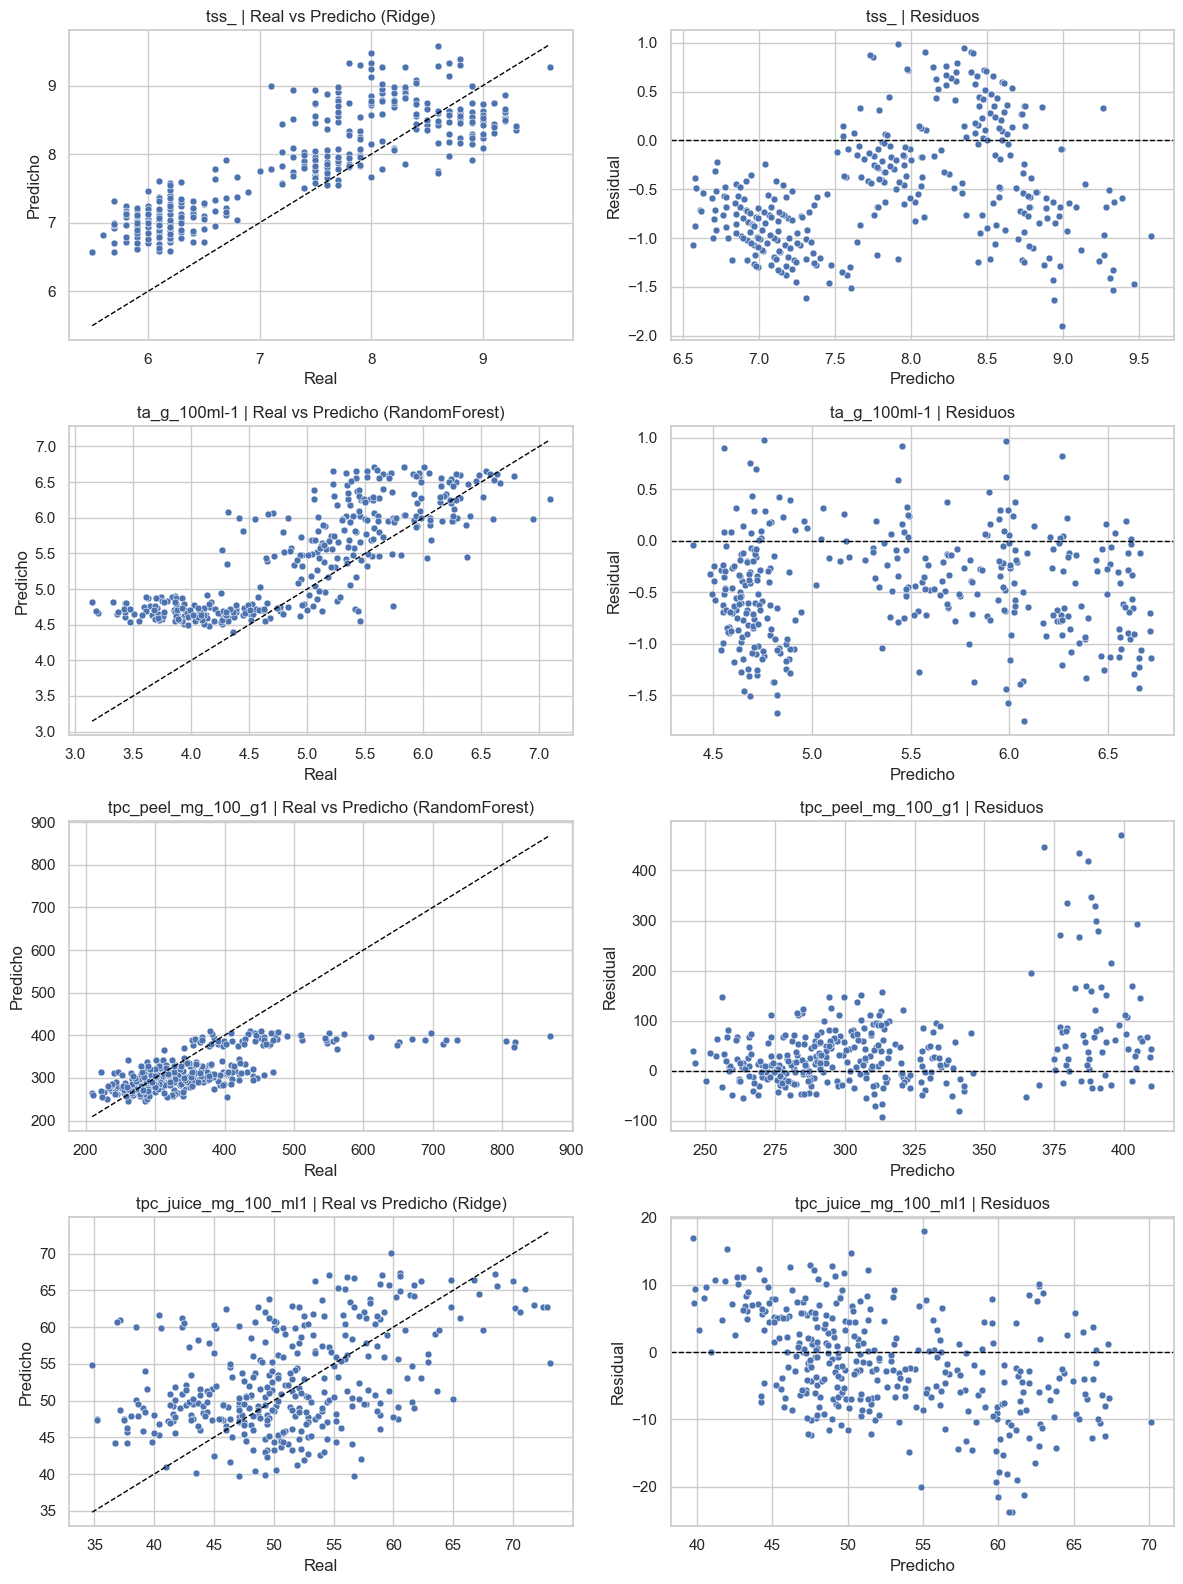

,target,model_tested,feature_set,mae_test,rmse_test,bias_mean_error,residual_std,abs_residual_p95
0,ta_g_100ml-1,RandomForest,full,0.567139,0.689830,-0.471157,0.503862,1.280877
1,tpc_juice_mg_100_ml1,Ridge,full,6.298591,7.708812,-1.558450,7.549636,14.517236
2,tpc_peel_mg_100_g1,RandomForest,full,54.735196,87.869575,40.161032,78.154678,162.087981
3,tss_,Ridge,full,0.679255,0.782981,-0.499381,0.603058,1.310677


Comparativa full vs spectral (delta < 0 en RMSE favorece full):


,target,best_full_rmse_val,best_spectral_rmse_val,delta_rmse_full_minus_spectral,best_full_r2_val,best_spectral_r2_val,delta_r2_full_minus_spectral
0,ta_g_100ml-1,0.485377,0.562028,-0.076651,0.766211,0.686541,0.079670
1,tpc_juice_mg_100_ml1,7.068097,7.620138,-0.552041,0.456371,0.368137,0.088234
2,tpc_peel_mg_100_g1,43.052416,46.139684,-3.087268,0.369844,0.276227,0.093617
3,tss_,0.406211,0.445208,-0.038998,0.817593,0.780889,0.036705


Tablas de análisis guardadas en: c:\Users\mirei\OneDrive\Escritorio\TFG\results\modelado\analysis


In [31]:
assert 'multi_target_validation' in globals(), "Ejecuta primero la celda del bucle multi-target (In [10])"

from sklearn.base import clone


def _default_pls_components(x_spec):
    if x_spec.shape[1] == 0:
        return 1
    return max(1, min(10, x_spec.shape[1], x_spec.shape[0] - 1))


def _select_estimator(model_name, x_spec, best_params):
    # Mapeo simple para mantener legible la selección de modelo.
    if model_name in {'PLS', 'PLSRegression_default', 'PLSRegression_tuned'}:
        n_comp = _default_pls_components(x_spec)
        if model_name == 'PLSRegression_tuned' and isinstance(best_params, dict):
            n_comp = int(best_params.get('n_components', n_comp))
        return get_baseline_models(pls_components=n_comp)['PLS']

    model_map = {
        'RandomForest': 'RandomForest',
        'LinearRegression': 'LinearRegression',
        'Ridge': 'Ridge',
        'Lasso': 'Lasso',
    }
    selected_key = model_map.get(model_name, 'LinearRegression')
    return get_baseline_models()[selected_key]


residual_rows = []
fig, axes = plt.subplots(len(available_targets), 2, figsize=(12, 4 * len(available_targets)))
if len(available_targets) == 1:
    axes = np.array([axes])

for i, target_name in enumerate(available_targets):
    bundle = build_dataset_for_target(df_raw, meta, target_name)
    Xt, Xs = bundle['X_train'], bundle['X_test']
    Xt_spec, Xs_spec = bundle['X_train_spec'], bundle['X_test_spec']
    yt, ys = bundle['y_train'], bundle['y_test']

    target_val = multi_target_validation[multi_target_validation['target'] == target_name].copy()
    best_row = target_val.sort_values(['rmse', 'mae']).iloc[0]
    model_name = best_row['model']
    feature_set = best_row['feature_set']

    estimator = _select_estimator(model_name, Xt_spec, best_row.get('best_params', None))

    if feature_set == 'spectral':
        X_fit, X_test_use = Xt_spec, Xs_spec
    else:
        X_fit, X_test_use = Xt, Xs

    model = clone(estimator)
    model.fit(X_fit, yt)
    y_pred = np.asarray(model.predict(X_test_use)).ravel()
    y_true = np.asarray(ys).ravel()
    residuals = y_true - y_pred

    base_metrics = regression_metrics(y_true, y_pred)
    bias = float(np.mean(residuals))
    std_res = float(np.std(residuals))
    q95 = float(np.quantile(np.abs(residuals), 0.95))

    residual_rows.append({
        'target': target_name,
        'model_tested': model_name,
        'feature_set': feature_set,
        'mae_test': base_metrics['mae'],
        'rmse_test': base_metrics['rmse'],
        'bias_mean_error': bias,
        'residual_std': std_res,
        'abs_residual_p95': q95,
    })

    ax1 = axes[i, 0]
    sns.scatterplot(x=y_true, y=y_pred, ax=ax1, s=25)
    min_val = min(float(np.min(y_true)), float(np.min(y_pred)))
    max_val = max(float(np.max(y_true)), float(np.max(y_pred)))
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='black', linewidth=1)
    ax1.set_title(f'{target_name} | Real vs Predicho ({model_name})')
    ax1.set_xlabel('Real')
    ax1.set_ylabel('Predicho')

    ax2 = axes[i, 1]
    sns.scatterplot(x=y_pred, y=residuals, ax=ax2, s=25)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_title(f'{target_name} | Residuos')
    ax2.set_xlabel('Predicho')
    ax2.set_ylabel('Residual')

plt.tight_layout()
plt.show()
plt.close(fig)

residual_summary = pd.DataFrame(residual_rows).sort_values('target').reset_index(drop=True)
display(residual_summary)

full_vs_spectral = multi_target_summary[[
    'target',
    'best_full_rmse_val',
    'best_spectral_rmse_val',
    'delta_rmse_full_minus_spectral',
    'best_full_r2_val',
    'best_spectral_r2_val',
    'delta_r2_full_minus_spectral',
]].sort_values('target').reset_index(drop=True)

print('Comparativa full vs spectral (delta < 0 en RMSE favorece full):')
display(full_vs_spectral)

analysis_dir = MODEL_ROOT_DIR / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)
residual_summary.to_csv(analysis_dir / 'residual_summary_best_models.csv', index=False)
full_vs_spectral.to_csv(analysis_dir / 'full_vs_spectral_comparison.csv', index=False)
print(f'Tablas de análisis guardadas en: {analysis_dir}')


## 7. Experimento: PCA como inputs

Bandas espectrales originales : 212 variables
Componentes PCA (95% varianza): 2 componentes
Reducción: 99.1%


,model,input,mae,rmse,r2
0,PLSRegression,Bandas crudas (212),0.658917,0.853499,0.194725
1,PLSRegression,PCA (2 comp.),0.660042,0.854285,0.193242
2,RandomForest,Bandas crudas (212),0.543764,0.686337,0.479270
3,RandomForest,PCA (2 comp.),0.576474,0.726447,0.416628
4,Ridge,Bandas crudas (212),0.507541,0.698040,0.461361
5,Ridge,PCA (2 comp.),0.660044,0.854270,0.193270


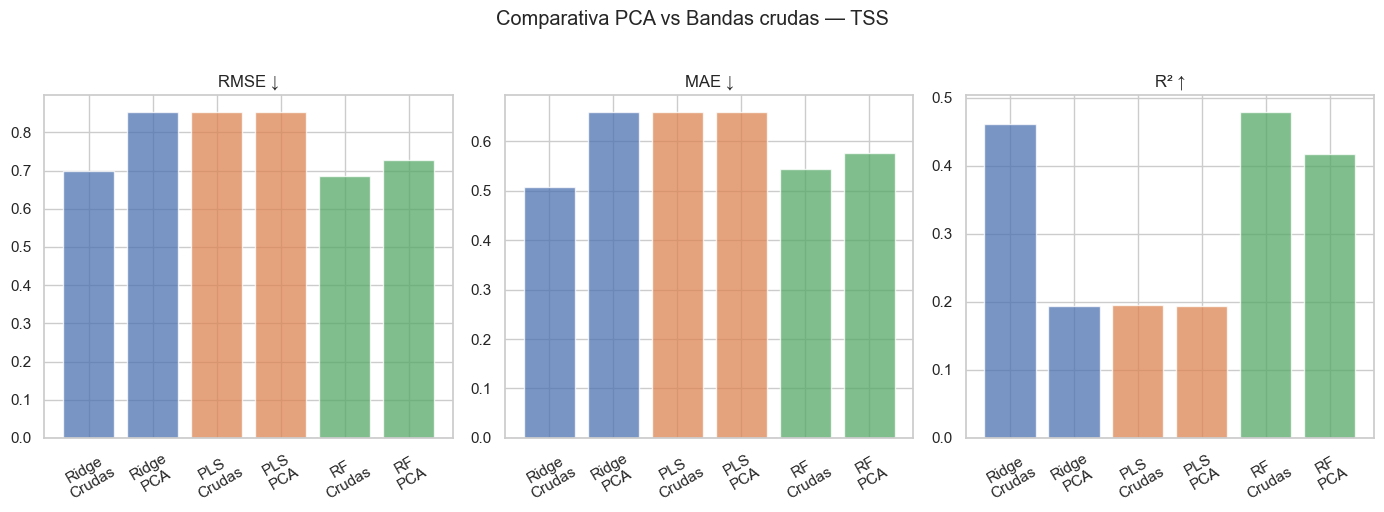


— Evaluación en TEST del mejor input por modelo —


,model,input,mae,rmse,r2
0,PLSRegression,Bandas crudas,0.707429,0.890518,0.361986
1,PLSRegression,PCA (2 comp.),0.710759,0.892733,0.358809
2,RandomForest,Bandas crudas,0.708729,0.837506,0.435687
3,RandomForest,PCA (2 comp.),0.768669,0.909834,0.334008
4,Ridge,Bandas crudas,0.725921,0.872771,0.387162
5,Ridge,PCA (2 comp.),0.710791,0.892739,0.358800


PCA 95% → 2 componentes
PCA 99% → 2 componentes


,input,RMSE val,R² val,RMSE test,R² test
0,Bandas crudas (212),0.69804,0.461361,0.872771,0.387162
1,PCA 95% (2 comp.),0.85427,0.193270,0.892739,0.358800
2,PCA 99% (2 comp.),0.85427,0.193270,0.892739,0.358800


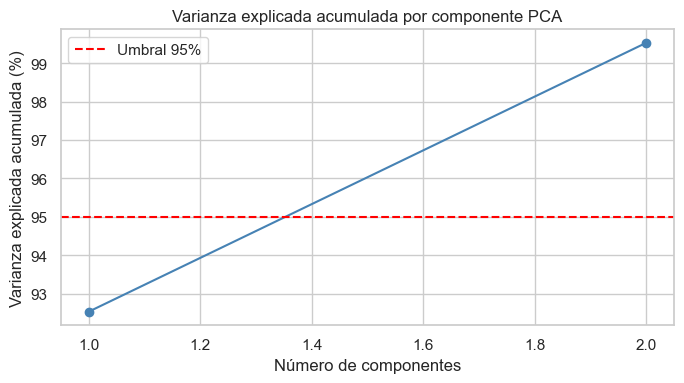

In [32]:

X_train_pca = data_bundle['X_train_spec_pca']
X_val_pca   = data_bundle['X_val_spec_pca']
X_test_pca  = data_bundle['X_test_spec_pca']
pca_spec    = data_bundle['pca_spec']
 
print(f"Bandas espectrales originales : {X_train_spec.shape[1]} variables")
print(f"Componentes PCA (95% varianza): {X_train_pca.shape[1]} componentes")
print(f"Reducción: {100*(1 - X_train_pca.shape[1]/X_train_spec.shape[1]):.1f}%")
 
from sklearn.base import clone
 
# Modelos a comparar en el experimento PCA
pca_models = {
    'Ridge':           clone(model_registry.get('Ridge', get_baseline_models()['Ridge'])),
    'PLSRegression':   clone(get_baseline_models(pls_components=max(1, min(10, X_train_pca.shape[1])))['PLS']),
    'RandomForest':    clone(get_baseline_models()['RandomForest']),
}
 
pca_results = []
for name, est in pca_models.items():
    # Con bandas crudas
    m_raw = clone(est)
    m_raw.fit(X_train_spec, y_train)
    pred_raw = np.asarray(m_raw.predict(X_val_spec)).ravel()
    met_raw = regression_metrics(y_val, pred_raw)
    met_raw.update({'model': name, 'input': 'Bandas crudas (212)'})
    pca_results.append(met_raw)
 
    # Con componentes PCA
    m_pca = clone(est)
    m_pca.fit(X_train_pca, y_train)
    pred_pca = np.asarray(m_pca.predict(X_val_pca)).ravel()
    met_pca = regression_metrics(y_val, pred_pca)
    met_pca.update({'model': name, 'input': f'PCA ({X_train_pca.shape[1]} comp.)'})
    pca_results.append(met_pca)
 
pca_df = pd.DataFrame(pca_results)[['model', 'input', 'mae', 'rmse', 'r2']]
pca_df = pca_df.sort_values(['model', 'rmse']).reset_index(drop=True)
display(pca_df)
 
# Nombres cortos para el gráfico
nombre_corto = {
    'Ridge': 'Ridge',
    'PLSRegression': 'PLS',
    'RandomForest': 'RF'
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_to_plot = [('rmse', 'RMSE ↓'), ('mae', 'MAE ↓'), ('r2', 'R² ↑')]
for ax, (metric, label) in zip(axes, metrics_to_plot):
    for model_name in pca_models:
        subset = pca_df[pca_df['model'] == model_name]
        etiquetas = [f"{nombre_corto.get(model_name, model_name)}\n{'Crudas' if 'crudas' in inp else 'PCA'}" 
                     for inp in subset['input']]
        ax.bar(etiquetas, subset[metric], alpha=0.75)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Comparativa PCA vs Bandas crudas — TSS', y=1.02)
plt.tight_layout()
plt.savefig('pca_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
 
# Evaluación en test del mejor input por modelo
print("\n— Evaluación en TEST del mejor input por modelo —")
test_pca_rows = []
for name, est in pca_models.items():
    for X_tr, X_ts, label in [
        (X_train_spec, X_test_spec, 'Bandas crudas'),
        (X_train_pca,  X_test_pca,  f'PCA ({X_train_pca.shape[1]} comp.)'),
    ]:
        m = clone(est)
        m.fit(X_tr, y_train)
        pred = np.asarray(m.predict(X_ts)).ravel()
        met = regression_metrics(y_test, pred)
        met.update({'model': name, 'input': label})
        test_pca_rows.append(met)
 
test_pca_df = pd.DataFrame(test_pca_rows)[['model', 'input', 'mae', 'rmse', 'r2']]
display(test_pca_df.sort_values(['model', 'rmse']).reset_index(drop=True))

# Experimento adicional: PCA con umbral de varianza mayor (99%)
from sklearn.decomposition import PCA

pca_99 = PCA(n_components=0.99, random_state=42)
X_train_pca99 = pca_99.fit_transform(X_train_spec)
X_val_pca99   = pca_99.transform(X_val_spec)
X_test_pca99  = pca_99.transform(X_test_spec)

print(f"PCA 95% → {X_train_pca.shape[1]} componentes")
print(f"PCA 99% → {X_train_pca99.shape[1]} componentes")

# Comparar Ridge con los tres inputs
ridge = get_baseline_models()['Ridge']
pca_extended = []
for label, X_tr, X_v, X_ts in [
    ('Bandas crudas (212)', X_train_spec, X_val_spec, X_test_spec),
    (f'PCA 95% ({X_train_pca.shape[1]} comp.)', X_train_pca, X_val_pca, X_test_pca),
    (f'PCA 99% ({X_train_pca99.shape[1]} comp.)', X_train_pca99, X_val_pca99, X_test_pca99),
]:
    m = clone(ridge)
    m.fit(X_tr, y_train)
    met_v = regression_metrics(y_val,  np.asarray(m.predict(X_v)).ravel())
    met_t = regression_metrics(y_test, np.asarray(m.predict(X_ts)).ravel())
    pca_extended.append({'input': label, 'RMSE val': met_v['rmse'], 'R² val': met_v['r2'],
                         'RMSE test': met_t['rmse'], 'R² test': met_t['r2']})

display(pd.DataFrame(pca_extended))

# Gráfico de varianza explicada acumulada
fig, ax = plt.subplots(figsize=(7, 4))
varianza_acumulada = np.cumsum(pca_spec.explained_variance_ratio_ * 100)
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='steelblue')
ax.axhline(95, color='red', linestyle='--', label='Umbral 95%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza explicada acumulada (%)')
ax.set_title('Varianza explicada acumulada por componente PCA')
ax.legend()
plt.tight_layout()
plt.savefig('varianza_explicada_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de muestras con error alto

Umbral error alto (P90 train): 0.6512
Muestras train con error alto: 43 (10.0%)
Muestras test  con error alto: 184 (52.6%)

Tabla de contingencia — Outlier morfológico vs Error alto:


Error de predicción alto (P90),False,True
Outlier morfológico (IQR),,
False,546,224
True,8,3



De las 227 muestras con error alto, 3 (1.3%) también son outliers morfológicos.
→ Poco solapamiento: el error alto refleja principalmente dificultad real del modelo.


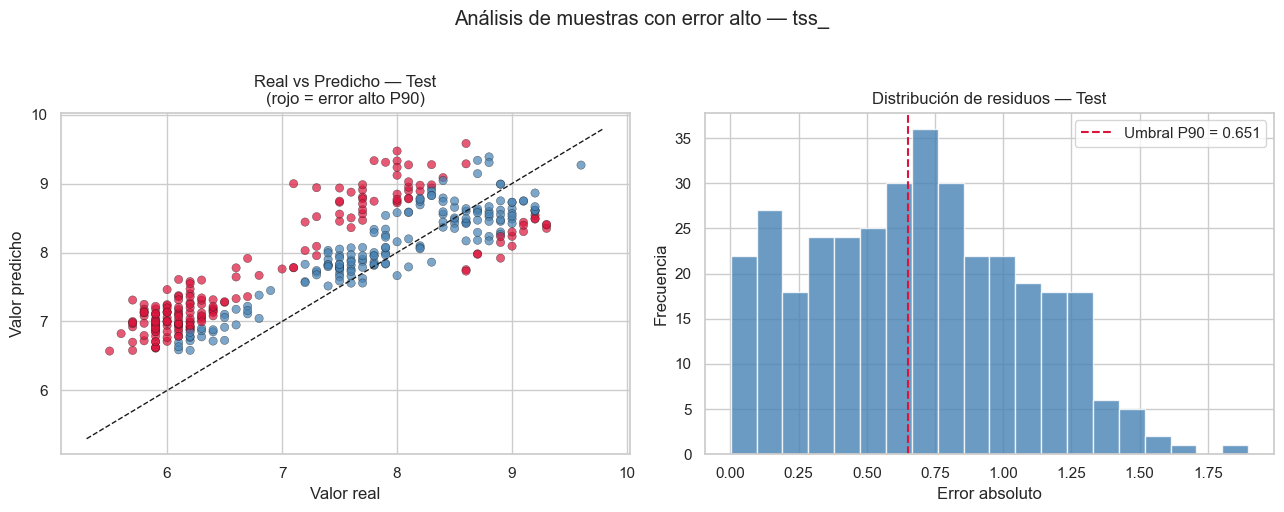

In [33]:

from src.outliers import univariate_outlier_table
from src.metrics import regression_metrics
 
OUTLIER_CSV = Path('results') / 'results_anomalias_univariantes_tfg.csv'
 
# Reentrenar el mejor modelo sobre train completo para obtener residuos de train
best_feature_set_sec8 = comparison_results.loc[
    comparison_results['model'] == best_overall_name, 'feature_set'
].iloc[0]
 
X_fit_sec8  = X_train_spec if best_feature_set_sec8 == 'spectral' else X_train
X_test_sec8 = X_test_spec  if best_feature_set_sec8 == 'spectral' else X_test
 
model_sec8 = clone(best_overall_model)
model_sec8.fit(X_fit_sec8, y_train)
 
# Residuos en train y en test
train_pred_sec8  = np.asarray(model_sec8.predict(X_fit_sec8)).ravel()
train_residuals  = np.abs(np.asarray(y_train).ravel() - train_pred_sec8)
 
test_pred_sec8   = np.asarray(model_sec8.predict(X_test_sec8)).ravel()
test_residuals   = np.abs(np.asarray(y_test).ravel() - test_pred_sec8)
 
# Umbral: muestras en el percentil 90 de error absoluto en train
threshold = float(np.percentile(train_residuals, 90))
high_error_train_idx = y_train.index[train_residuals > threshold]
high_error_test_idx  = y_test.index[test_residuals > threshold]
 
print(f"Umbral error alto (P90 train): {threshold:.4f}")
print(f"Muestras train con error alto: {len(high_error_train_idx)} "
      f"({100*len(high_error_train_idx)/len(y_train):.1f}%)")
print(f"Muestras test  con error alto: {len(high_error_test_idx)} "
      f"({100*len(high_error_test_idx)/len(y_test):.1f}%)")
 
# Detectar outliers IQR sobre variables morfológicas en el dataframe original
# (mismas muestras que están en train+test)
all_idx = list(X_train.index) + list(X_test.index)
df_analysis = df_raw.loc[df_raw.index.intersection(all_idx)].copy()
 
morf_present = [c for c in morf_cols if c in df_analysis.columns]
outlier_flags = pd.DataFrame(index=df_analysis.index)
 
if morf_present:
    for col in morf_present:
        serie = pd.to_numeric(df_analysis[col], errors='coerce').dropna()
        q1 = float(np.percentile(serie, 25))
        q3 = float(np.percentile(serie, 75))
        iqr = q3 - q1
        outlier_flags[f'{col}_outlier_iqr'] = (
            (df_analysis[col] < q1 - 1.5 * iqr) | (df_analysis[col] > q3 + 1.5 * iqr)
        )
    outlier_flags['es_outlier_morfologico'] = outlier_flags.any(axis=1)
else:
    outlier_flags['es_outlier_morfologico'] = False
 
# Cruce: error alto vs outlier morfológico
high_error_all_idx = list(high_error_train_idx) + list(high_error_test_idx)
outlier_flags['error_alto'] = outlier_flags.index.isin(high_error_all_idx)
 
crosstab = pd.crosstab(
    outlier_flags['es_outlier_morfologico'],
    outlier_flags['error_alto'],
    rownames=['Outlier morfológico (IQR)'],
    colnames=['Error de predicción alto (P90)'],
)
print("\nTabla de contingencia — Outlier morfológico vs Error alto:")
display(crosstab)
 
# Interpretación automática
n_coincide = int(crosstab.loc[True, True]) if (True in crosstab.index and True in crosstab.columns) else 0
n_error_alto = int(outlier_flags['error_alto'].sum())
pct = 100 * n_coincide / n_error_alto if n_error_alto > 0 else 0
print(f"\nDe las {n_error_alto} muestras con error alto, "
      f"{n_coincide} ({pct:.1f}%) también son outliers morfológicos.")
if pct >= 40:
    print("→ Hay solapamiento notable: parte del error puede deberse a anomalías de medida.")
else:
    print("→ Poco solapamiento: el error alto refleja principalmente dificultad real del modelo.")
 
# Gráfico: residuos test coloreados por si son outlier morfológico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Scatter real vs predicho, color = error alto
colors_test = ['crimson' if idx in high_error_test_idx else 'steelblue'
               for idx in y_test.index]
axes[0].scatter(np.asarray(y_test).ravel(), test_pred_sec8,
                c=colors_test, alpha=0.7, edgecolors='k', linewidths=0.3)
lims = [min(np.asarray(y_test).min(), test_pred_sec8.min()) - 0.2,
        max(np.asarray(y_test).max(), test_pred_sec8.max()) + 0.2]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Real vs Predicho — Test\n(rojo = error alto P90)')
 
# Distribución de residuos con umbral
axes[1].hist(test_residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(threshold, color='crimson', linestyle='--', lw=1.5,
                label=f'Umbral P90 = {threshold:.3f}')
axes[1].set_xlabel('Error absoluto')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos — Test')
axes[1].legend()
 
plt.suptitle(f'Análisis de muestras con error alto — {TARGET_NAME}', y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

## 9. Cierre: ¿las anomalías de PyOD afectan a la predicción?

Consenso PyOD cargado desde results\consensus_pyod.csv

Error medio en train — anomalías PyOD  : 0.3815
Error medio en train — muestras normales: 0.3240
Mann-Whitney (anomalías > normales): p=0.0794
→ No hay diferencia significativa en el error de predicción.
  Las anomalías espectrales son sutiles y no necesariamente más difíciles de predecir.

Tabla de contingencia final — Anomalía PyOD vs Error alto de predicción:


Error alto (P90 > 0.651),False,True
Anomalía de consenso PyOD,,
False,370,40
True,18,3


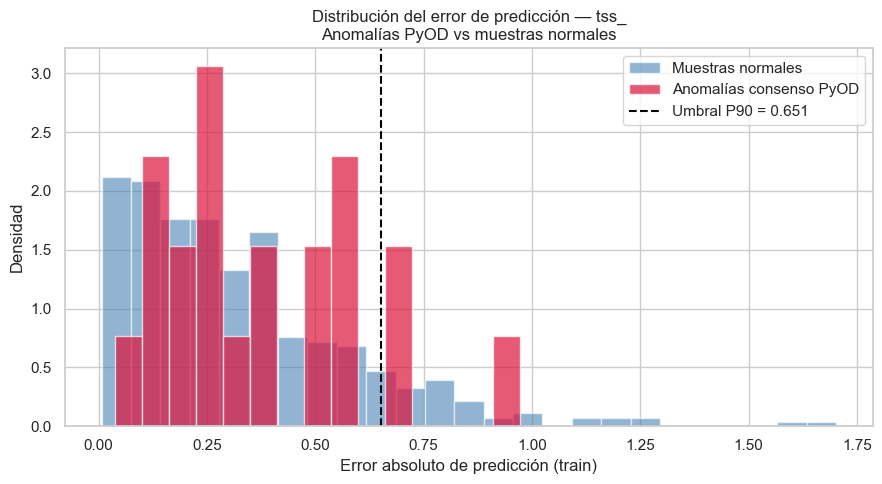

In [34]:
 
from src.anomaly_detection import get_anomaly_detectors, run_anomaly_detection, consensus_anomalies
 
CONSENSUS_PATH = Path('results') / 'consensus_pyod.csv'
 
if CONSENSUS_PATH.exists():
    consensus_pyod = pd.read_csv(CONSENSUS_PATH, index_col=0)
    consensus_pyod['is_consensus_anomaly'] = consensus_pyod['is_consensus_anomaly'].astype(bool)
    print(f"Consenso PyOD cargado desde {CONSENSUS_PATH}")
else:
    # Recalcular si no se guardó previamente
    print("Recalculando consenso PyOD sobre X_train_spec...")
    detectors = get_anomaly_detectors(contamination=0.05, random_state=42)
    results_spec = run_anomaly_detection(X_train_spec, detectors=detectors)
    consensus_pyod = consensus_anomalies(results_spec, min_models=3)
    print(f"Consenso calculado: {consensus_pyod['is_consensus_anomaly'].sum()} anomalías de consenso")
 
# Índices de las anomalías de consenso PyOD que están en train
pyod_anomaly_idx = consensus_pyod.index[consensus_pyod['is_consensus_anomaly']]
pyod_in_train = [idx for idx in pyod_anomaly_idx if idx in y_train.index]
 
# Error de predicción en train para cada muestra
train_error_series = pd.Series(train_residuals, index=y_train.index)
 
error_pyod_anomaly = train_error_series.loc[
    [i for i in pyod_in_train if i in train_error_series.index]
]
error_pyod_normal = train_error_series.loc[
    [i for i in train_error_series.index if i not in pyod_anomaly_idx]
]
 
print(f"\nError medio en train — anomalías PyOD  : {error_pyod_anomaly.mean():.4f}")
print(f"Error medio en train — muestras normales: {error_pyod_normal.mean():.4f}")
 
# Test estadístico: ¿tienen más error las anomalías de PyOD?
from scipy.stats import mannwhitneyu
if len(error_pyod_anomaly) >= 3:
    stat, pval = mannwhitneyu(error_pyod_anomaly, error_pyod_normal, alternative='greater')
    print(f"Mann-Whitney (anomalías > normales): p={pval:.4f}")
    if pval < 0.05:
        print("→ Las anomalías de consenso PyOD generan significativamente más error de predicción.")
        print("  Esto confirma que las anomalías espectrales multivariantes impactan en la predicción.")
    else:
        print("→ No hay diferencia significativa en el error de predicción.")
        print("  Las anomalías espectrales son sutiles y no necesariamente más difíciles de predecir.")
 
# Tabla de contingencia final: error alto P90 vs anomalía PyOD
high_error_flag = pd.Series(False, index=y_train.index)
high_error_flag.loc[[i for i in high_error_train_idx if i in y_train.index]] = True
 
pyod_flag = pd.Series(False, index=y_train.index)
pyod_flag.loc[[i for i in pyod_in_train if i in y_train.index]] = True
 
crosstab_final = pd.crosstab(
    pyod_flag,
    high_error_flag,
    rownames=['Anomalía de consenso PyOD'],
    colnames=[f'Error alto (P90 > {threshold:.3f})'],
)
print("\nTabla de contingencia final — Anomalía PyOD vs Error alto de predicción:")
display(crosstab_final)
 
# Gráfico: distribución de error en train, separando anomalías PyOD vs normales
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(error_pyod_normal, bins=25, alpha=0.6, color='steelblue',
        label='Muestras normales', density=True)
ax.hist(error_pyod_anomaly, bins=15, alpha=0.7, color='crimson',
        label='Anomalías consenso PyOD', density=True)
ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
           label=f'Umbral P90 = {threshold:.3f}')
ax.set_xlabel('Error absoluto de predicción (train)')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución del error de predicción — {TARGET_NAME}\nAnomalías PyOD vs muestras normales')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)